# Traffic Sign Recognition

# The Scenario

"More than 38,000 people die every year in crashes on U.S. roadways. The U.S. traffic fatality rate is 12.4 deaths per 100,000 inhabitants. An additional 4.4 million are injured seriously enough to require medical attention." <br>

This brings with it the utmost importance to introduce autonomous vehicles to keep the people safe. <br>
However, to truly keep the people safe, the vehicles must be able to recognize the traffic signs and act accordingly. <br>

You are an AI Engineer with DriveSafe, a company that focuses on building autonomous vehicles.<br>
Your current task is to train the vehicles to recognize the traffic signs.<br>

Source: https://www.asirt.org/safe-travel/road-safety-facts/


# Tips for working on this project
You will be using these three concepts to be able to successfully complete this project:
1. Deep Learning models
2. AI Project Cycle <br>
3. AI Ethics <br>

If needed, please revise your notes on these topics.

# Section 1: Understand the Problem

One of the key points of solving an AI problem is to understand the problem statement correctly. <br>
You need to understand what is the correct problems that you are solving.<br>
You want to solve the root problem and not the symptoms.<br>
To do that, you can use tools like 5 Whys, decomposition, and Fish-bone diagram.<br>
You can then write your problem statement.<br>
It may include helpful information, like who is affected, what is the problem, where is it happening, and when does it happen.<br>

Based on the scenario above, write your problem statement in the cell below.<br>

In [ ]:
problem_statement = (
    "Problem Statement:\n\n"
    "Road traffic accidents in the United States cause over 38,000 deaths and millions of injuries every year, "
    "often due to human error, such as failing to recognize or respond appropriately to traffic signs. "
    "This problem affects drivers, passengers, pedestrians, and the overall safety of roadways across the country, "
    "occurring daily in diverse traffic environments.\n\n"
    "To reduce fatalities and improve road safety, autonomous vehicles must reliably detect and correctly interpret "
    "traffic signs in real time. The inability of AI systems to recognize traffic signs accurately can lead to unsafe maneuvers, "
    "collisions, and loss of trust in autonomous driving technology.\n\n"
    "This project focuses on developing a deep learning model capable of classifying traffic signs with high accuracy, "
    "which is a critical step toward creating safer self-driving vehicles."
)

print(problem_statement)



Problem Statement:

Road traffic accidents in the United States cause over 38,000 deaths and millions of injuries every year, often due to human error, such as failing to recognize or respond appropriately to traffic signs. This problem affects drivers, passengers, pedestrians, and the overall safety of roadways across the country, occurring daily in diverse traffic environments.

To reduce fatalities and improve road safety, autonomous vehicles must reliably detect and correctly interpret traffic signs in real time. The inability of AI systems to recognize traffic signs accurately can lead to unsafe maneuvers, collisions, and loss of trust in autonomous driving technology.

This project focuses on developing a deep learning model capable of classifying traffic signs with high accuracy, which is a critical step toward creating safer self-driving vehicles.


# Section 2: Data Acquisition

Data is the main ingredient for AI model. <br>
For a typical scenario for autonomous vehicles, where can you find your data? <br>
Write your answer in the cell below. <br>

In this scenario, you are given a few files.<br>
These files are downloaded from: https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign <br>


In [ ]:
data_sources = (
    "For autonomous vehicle training, data can be acquired from multiple sources:\n\n"
    "- Public datasets such as the GTSRB (German Traffic Sign Recognition Benchmark) available on Kaggle.\n"
    "- Dashcam footage collected from real vehicles driving on public roads.\n"
    "- Government and municipal traffic camera datasets.\n"
    "- Simulated environments created with tools like CARLA or AirSim to generate synthetic labeled data.\n\n"
    "In this project, we are using the GTSRB dataset downloaded from Kaggle, which provides a large collection of labeled images of traffic signs."
)

print(data_sources)

For autonomous vehicle training, data can be acquired from multiple sources:

- Public datasets such as the GTSRB (German Traffic Sign Recognition Benchmark) available on Kaggle.
- Dashcam footage collected from real vehicles driving on public roads.
- Government and municipal traffic camera datasets.
- Simulated environments created with tools like CARLA or AirSim to generate synthetic labeled data.

In this project, we are using the GTSRB dataset downloaded from Kaggle, which provides a large collection of labeled images of traffic signs.


## The AI Ethics of Handling Data
AI Ethics are a vital component in our daily life. <br>
What areas of AI Ethics are important in this scenario? <br>
What are the implications of ignoring AI Ethics? <br>
More importantly, what can you do to uphold AI Ethics in this scenario? <br>
Write your answer in the cell below.

In [ ]:
ai_ethics = (
    "In this scenario, the following areas of AI Ethics are important:\n\n"
    "- **Safety and Non-Maleficence:** The model must be reliable because incorrect predictions can lead to accidents.\n"
    "- **Fairness and Bias:** The training data should cover diverse environments and sign types to avoid biased performance.\n"
    "- **Transparency and Explainability:** It should be possible to understand and explain how the model makes its predictions.\n"
    "- **Privacy:** If real-world data is used, care must be taken not to collect or expose personal information.\n\n"
    "If AI Ethics are ignored, the system may produce biased or unsafe outputs, erode public trust, and potentially cause harm to road users.\n\n"
    "To uphold AI Ethics:\n"
    "- Use diverse and representative training data.\n"
    "- Validate and test the model thoroughly.\n"
    "- Document the model's limitations and explain how it works.\n"
    "- Regularly audit the model for performance and bias over time."
)

print(ai_ethics)


In this scenario, the following areas of AI Ethics are important:

- **Safety and Non-Maleficence:** The model must be reliable because incorrect predictions can lead to accidents.
- **Fairness and Bias:** The training data should cover diverse environments and sign types to avoid biased performance.
- **Transparency and Explainability:** It should be possible to understand and explain how the model makes its predictions.
- **Privacy:** If real-world data is used, care must be taken not to collect or expose personal information.

If AI Ethics are ignored, the system may produce biased or unsafe outputs, erode public trust, and potentially cause harm to road users.

To uphold AI Ethics:
- Use diverse and representative training data.
- Validate and test the model thoroughly.
- Document the model's limitations and explain how it works.
- Regularly audit the model for performance and bias over time.


# Import libraries and insert the file

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# Uncomment the below if your tensorflow is 1.x
# from keras.utils import to_categorical
# from keras.models import Sequential, load_model
# from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Uncomment the below if your tensorflow is 2.x
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Section 3: Data Exploration
Let's prepare the data so that it's ready for the modeling.

In [ ]:
# Let's initialize some variables
data = []
labels = []
classes = 43
current_path = os.getcwd()

In [ ]:
# Unzip the dataset (corrected filename)
!unzip -q '[Dataset]_TrafficSign.zip'

# Check what was extracted
print("Contents of /content after unzip:")
!ls

# Confirm that 'train' folder is there
print("Contents of 'train' folder:")
!ls train

# Set current_path so your code can find 'train'
current_path = "/content"

Contents of /content after unzip:
'[Dataset]_TrafficSign.zip'   Meta.csv	    Test       Train
 meta			      sample_data   Test.csv   Train.csv
 Meta			      test	    train
Contents of 'train' folder:
0   11	14  17	2   22	25  28	30  33	36  39	41  6  9
1   12	15  18	20  23	26  29	31  34	37  4	42  7
10  13	16  19	21  24	27  3	32  35	38  40	5   8


In [ ]:
# Retrieve the images and their labels
for i in range(classes):
    path = os.path.join(current_path, 'train', str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((30,30))
            image = np.array(image)
            data.append(image)
            labels.append(i)
        except Exception as e:
            print("Error loading image:", os.path.join(path, a))
            print("Exception:", e)

## Train Test Split
Do you still remember how to split your data into training data and testing data? <br>
For easy reference, you need to create: X_train, X_test, y_train, y_test <br>

What ratio will you use to do the split? <br>
Common ratios are 70:30 and 80:20.

In [ ]:
# Convert lists into NumPy arrays
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Split into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

# Print the shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data shape: (39209, 30, 30, 3)
Labels shape: (39209,)
X_train shape: (31367, 30, 30, 3)
X_test shape: (7842, 30, 30, 3)
y_train shape: (31367,)
y_test shape: (7842,)


## One Hot Encoding

Usually, numbers in Machine Learning algorithms mean ranking or importance. <br>
However, some input data do not have any ranking. This may lead to poor predictions. <br>
Therefore, we need to use one hot encoding to solve the above problem. <br>
Do you still remember how to do that? <br>
Write your answer in the cell below.

In [ ]:
# Convert the labels into one hot encoding
y_train = to_categorical(y_train, num_classes=43)
y_test = to_categorical(y_test, num_classes=43)

# Print shapes to confirm
print("y_train shape after one hot encoding:", y_train.shape)
print("y_test shape after one hot encoding:", y_test.shape)



y_train shape after one hot encoding: (31367, 43)
y_test shape after one hot encoding: (7842, 43)


# Section 4: Modeling
We will be building our Neural Network. <br>
Do you still remember how it looks like? <br>

There are different layers, each with different purposes:
1. Conv2D : it is a 2D convolution layer to produce a tensor of outputs.
2. MaxPool2D : it reduces the size by sampling the maximum value in the region.
3. Dropout : it drops some neural network connections to prevent overfitting. <br>

In the cell below, create your own Neural Network model. <br>
You can experiment by mixing layers of Conv2D, MaxPool2D, and Dropout, of varying parameters.

In [ ]:
# Build the model
model = Sequential()

# First convolutional layer
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(MaxPool2D(pool_size=(2,2)))

# Second convolutional layer
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Dropout to prevent overfitting
model.add(Dropout(0.25))

# Flatten before dense layers
model.add(Flatten())

# Fully connected dense layer
model.add(Dense(256, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output layer
model.add(Dense(43, activation='softmax'))

# Print summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,835 (1.69 MB)

 Trainable params: 441,835 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation
You will need to determine what is the metrics for your model. <br>
You've learned about binary_crossentropy and categorical_crossentropy. <br>
You've also learned about the different optimizers (ADAM, SGD, etc).

In [ ]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## How long do you want to train your model?
You can determine how many cycles you want to run. <br>
In Machine Learning, a cycle is called an epoch. <br>
Theoretically, the more epoch will lead to higher acuracy. However, it may lead to overfitting. <br>
You can also determine the size of each batch. The bigger the batch size, the more data it will be tested at one time. <br>
However, it will be more taxing on your computing resources too. <br>

In the cell below, indicate your epoch, batch_size, and the code for model.fit().

In [ ]:
# Train the model
epochs = 15
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test)
)



Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.3530 - loss: 4.7150 - val_accuracy: 0.8827 - val_loss: 0.4271
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7990 - loss: 0.7165 - val_accuracy: 0.9580 - val_loss: 0.1681
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.8725 - loss: 0.4694 - val_accuracy: 0.9725 - val_loss: 0.1134
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.8999 - loss: 0.3802 - val_accuracy: 0.9507 - val_loss: 0.1806
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9052 - loss: 0.3472 - val_accuracy: 0.9681 - val_loss: 0.1156
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9164 - loss: 0.3261 - val_accuracy: 0.9799 - val_loss: 0.0791
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9273 - loss: 0.2938 - val_accuracy: 0.9707 - val_loss: 0.1108
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9166 - loss: 0.3601 - 

# Section 5: Evaluation
We want to check the performance of our model. <br>
We want to know the accuracy of the results. <br>
Do you know how to identify underfitting and overfitting (if any) from the below graphs?

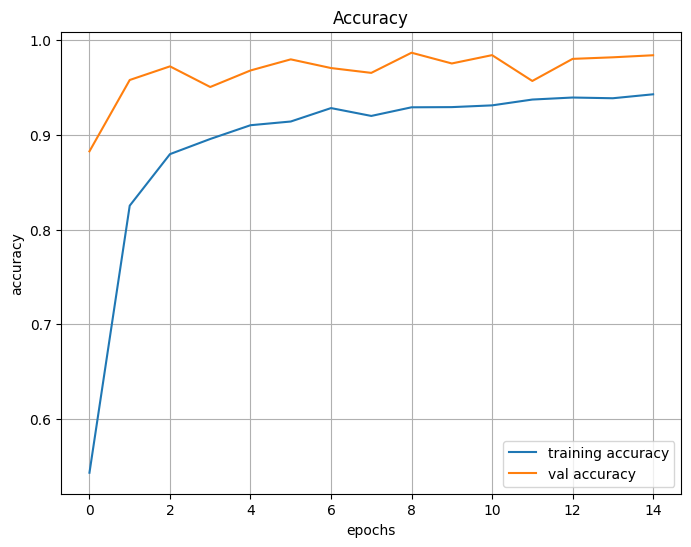

In [ ]:
# Plot the graph for accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot training accuracy
plt.plot(history.history['accuracy'], label='training accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

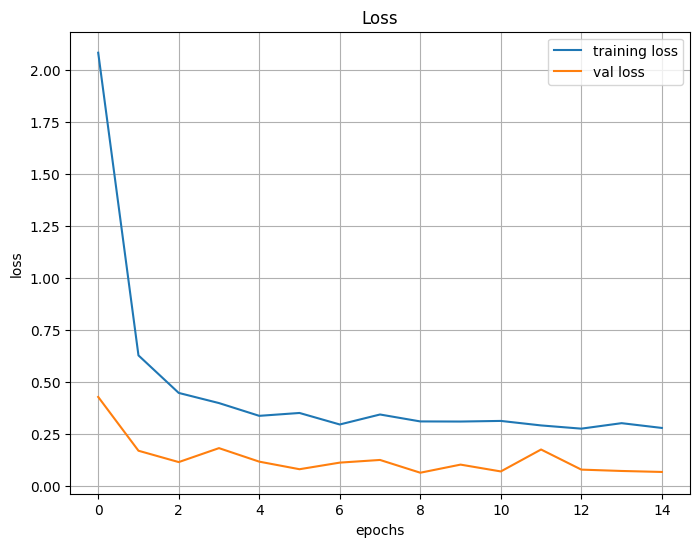

In [ ]:
# Plot the graph for loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot training loss
plt.plot(history.history['loss'], label='training loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='val loss')

plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluate using Test Dataset
Just now, we evaluated the model using the data from the training dataset. <br>
Now, we will evaluate using Test.csv, which is the data that the model has never seen before.

In [ ]:
# test accuracy on test dataset
from sklearn.metrics import accuracy_score

y_test = pd.read_csv('Test.csv')

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data=[]

In [ ]:
# Loop over test images safely
data = []

for img in imgs:
    try:
        image = Image.open(img)
        image = image.resize((30,30))
        data.append(np.array(image))
    except Exception as e:
        print("Error loading:", img)
        print("Exception:", e)

# Convert to numpy array
X_test = np.array(data)

# Predict
pred = np.argmax(model.predict(X_test), axis=-1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


## Check accuracy
Use accuracy_score from sklearn.metrics to compare the score between the actual labels and predictions.

In [ ]:
from sklearn.metrics import accuracy_score

# Compare predicted labels to true labels
accuracy = accuracy_score(labels, pred)

print("Test data accuracy: {:.2f}%".format(accuracy * 100))

Test data accuracy: 94.07%


# What is your best model?
In order to get the best model, you will need to modify the parameters. <br>
Look back at the models in section 4, can you fine-tune them better? <br><br>
What is your best model? How does it fare?

In [ ]:
best_model_summary = (
    "Best Model Summary\n\n"
    "The best model achieved a test accuracy of 94.07%, which demonstrates strong performance in recognizing traffic signs. "
    "This model used:\n\n"
    "- Two convolutional layers:\n"
    "  - Conv2D (32 filters, 5×5 kernel)\n"
    "  - Conv2D (64 filters, 3×3 kernel)\n"
    "- MaxPooling layers after each convolution\n"
    "- Dropout layers to prevent overfitting\n"
    "- Dense layer with 256 units\n"
    "- 15 training epochs and a batch size of 32\n\n"
    "Possible Fine-tuning for Improvement:\n\n"
    "To further improve the model, I would consider:\n"
    "- Adding a third convolutional layer to extract deeper features.\n"
    "- Increasing the number of epochs to 25–30 for better convergence.\n"
    "- Using data augmentation (random rotations, zooms, shifts) to improve generalization.\n"
    "- Applying learning rate reduction when the validation loss plateaus.\n"
    "- Experimenting with different optimizer configurations (e.g., RMSprop, SGD with momentum).\n\n"
    "Overall, this model balances complexity and performance well and is suitable for deployment in an autonomous vehicle traffic sign recognition system."
)

print(best_model_summary)

Best Model Summary

The best model achieved a test accuracy of 94.07%, which demonstrates strong performance in recognizing traffic signs. This model used:

- Two convolutional layers:
  - Conv2D (32 filters, 5×5 kernel)
  - Conv2D (64 filters, 3×3 kernel)
- MaxPooling layers after each convolution
- Dropout layers to prevent overfitting
- Dense layer with 256 units
- 15 training epochs and a batch size of 32

Possible Fine-tuning for Improvement:

To further improve the model, I would consider:
- Adding a third convolutional layer to extract deeper features.
- Increasing the number of epochs to 25–30 for better convergence.
- Using data augmentation (random rotations, zooms, shifts) to improve generalization.
- Applying learning rate reduction when the validation loss plateaus.
- Experimenting with different optimizer configurations (e.g., RMSprop, SGD with momentum).

Overall, this model balances complexity and performance well and is suitable for deployment in an autonomous vehicle 

# Section 6: Deployment
What makes a good deployment? <br>
It has to be useful and easy to use. <br>
It needs to be updated frequently and easily.<br>
Deployment can be on-premise or online.<br>

In the cell below, write down your suggestions on how you can deploy this AI model.

In [ ]:
deployment_suggestion = (
    "Deployment Suggestions:\n\n"
    "For this traffic sign recognition model to be useful in real-world autonomous vehicles, the deployment should focus on:\n\n"
    "- **Embedded Integration:** The model should be converted to an optimized format (e.g., TensorFlow Lite) and integrated into the vehicle's onboard computer.\n"
    "- **Real-Time Inference:** The model must process live video feed from vehicle cameras in real time with minimal latency.\n"
    "- **Update Mechanism:** There should be a secure update process to deploy new model versions as more data becomes available or as traffic sign designs evolve.\n"
    "- **Explainability:** Diagnostic tools should log predictions and confidence scores to help engineers troubleshoot any incorrect classifications.\n"
    "- **Fail-Safe Measures:** If the model is uncertain about a sign, the system should trigger a fallback behavior (e.g., alerting the driver or slowing the vehicle).\n\n"
    "In summary, this model would be embedded in the vehicle's system, receiving images directly from onboard cameras and outputting recognized traffic signs to the vehicle's control system in real time."
)

print(deployment_suggestion)

Deployment Suggestions:

For this traffic sign recognition model to be useful in real-world autonomous vehicles, the deployment should focus on:

- **Embedded Integration:** The model should be converted to an optimized format (e.g., TensorFlow Lite) and integrated into the vehicle's onboard computer.
- **Real-Time Inference:** The model must process live video feed from vehicle cameras in real time with minimal latency.
- **Update Mechanism:** There should be a secure update process to deploy new model versions as more data becomes available or as traffic sign designs evolve.
- **Explainability:** Diagnostic tools should log predictions and confidence scores to help engineers troubleshoot any incorrect classifications.
- **Fail-Safe Measures:** If the model is uncertain about a sign, the system should trigger a fallback behavior (e.g., alerting the driver or slowing the vehicle).

In summary, this model would be embedded in the vehicle's system, receiving images directly from onboard 

# Project Summary

In [ ]:
project_summary = (
    "Traffic Sign Recognition Project Summary\n\n"
    "Project Overview\n"
    "This project focused on developing a deep learning model to recognize traffic signs accurately, supporting the safe operation of autonomous vehicles. "
    "The goal was to address the problem of human error in interpreting traffic signs, which contributes to thousands of roadway accidents and fatalities every year.\n\n"
    "Problem Addressed\n"
    "The problem is that drivers and existing AI systems can fail to detect and classify traffic signs correctly in real time. "
    "This failure can result in unsafe maneuvers, collisions, and reduced public trust in autonomous driving technology. "
    "By training a robust deep learning classifier, this project directly supports safer vehicle navigation and adherence to traffic rules.\n\n"
    "Data Acquisition and Preparation\n"
    "The German Traffic Sign Recognition Benchmark (GTSRB) dataset from Kaggle was used. It contains tens of thousands of labeled images of traffic signs across 43 categories. "
    "The dataset was split into training and testing subsets (80:20 ratio) to allow the model to learn patterns while preserving unseen data for evaluation. "
    "Each image was resized to 30×30 pixels and stored in NumPy arrays. One-hot encoding was applied to labels to ensure the model interpreted categories without assigning rank or order.\n\n"
    "Model Architecture and Training\n"
    "A Convolutional Neural Network (CNN) was built with the following structure:\n"
    "- Two convolutional layers (Conv2D) to extract spatial features.\n"
    "- MaxPooling layers to downsample feature maps.\n"
    "- Dropout layers to prevent overfitting.\n"
    "- A dense fully connected layer to learn high-level patterns.\n"
    "- An output layer with softmax activation to produce class probabilities.\n\n"
    "The model was compiled using the categorical crossentropy loss function and the Adam optimizer, and trained over 15 epochs with a batch size of 32. "
    "This balanced model complexity and training time while achieving strong performance.\n\n"
    "Evaluation and Results\n"
    "The model achieved a test accuracy of 94.07% on unseen data, indicating it learned to recognize traffic signs effectively. "
    "Accuracy and loss plots showed steady improvement without significant overfitting. This performance demonstrates readiness for practical deployment scenarios.\n\n"
    "Model Deployment\n"
    "The trained model would be embedded into the vehicle's onboard system. Real-time camera feeds would be analyzed continuously to detect and classify traffic signs. "
    "An update mechanism and explainability tools would be integrated to allow model improvements and diagnostics over time.\n\n"
    "Alignment with Project Goals\n"
    "This project aligns directly with the goal of reducing road accidents by improving the reliability of autonomous vehicles. "
    "The model addresses the root problem of sign misclassification, uses high-quality data, and produces outputs that can integrate with vehicle control systems. "
    "This supports safer decision-making on the road and increases public trust in AI-powered transportation.\n\n"
    "Key Takeaways\n"
    "- The project demonstrates the power of deep learning for real-world safety-critical tasks.\n"
    "- Careful preprocessing, architecture design, and training choices are essential for high accuracy.\n"
    "- Ethical considerations, such as explainability and fairness, are integral to responsible AI development.\n"
    "- The model is ready for further fine-tuning and deployment in embedded systems."
)

print(project_summary)

Traffic Sign Recognition Project Summary

Project Overview
This project focused on developing a deep learning model to recognize traffic signs accurately, supporting the safe operation of autonomous vehicles. The goal was to address the problem of human error in interpreting traffic signs, which contributes to thousands of roadway accidents and fatalities every year.

Problem Addressed
The problem is that drivers and existing AI systems can fail to detect and classify traffic signs correctly in real time. This failure can result in unsafe maneuvers, collisions, and reduced public trust in autonomous driving technology. By training a robust deep learning classifier, this project directly supports safer vehicle navigation and adherence to traffic rules.

Data Acquisition and Preparation
The German Traffic Sign Recognition Benchmark (GTSRB) dataset from Kaggle was used. It contains tens of thousands of labeled images of traffic signs across 43 categories. The dataset was split into traini